## Master in Artificial Intelligence, UdC, USC, UVigo. 2025/2026
## COMPUTER VISION I

### Topic 4: Image Segmentation
### Part 1: intensity-based thresholding and clustering (0.80 pts.)
Remember: digital images are just two-dimensional data.
To segment a certain type of images,
we always need some prior knowledge of the information
that is available in the data. Here, we assume that the useful information
is given by more or less similar gray values and that the foreground
consist of typical objects as seen in out daily live.

Make sure the path to the image file meets your needs on your system.

In [4]:
images_path = './images/'

We import everything at the beginning, as the libs are needed later...

In [5]:
# !pip install seaborn opencv-python scikit-learn scipy matplotlib numpy

In [6]:
import cv2
import sys
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import mixture
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift, estimate_bandwidth
from scipy.stats import norm
from sklearn.cluster import DBSCAN

We instruct matplotlib to show gridlines in the visualization of
two-dimensional data (maybe this is already the default in your
environment).
Decide by yourself whether you like them to be displayed.

In [7]:
plt.rcParams.update({"axes.grid" : True})

#### Histogram thresholding

**Exercise 1:**
Read and visualize 'plates.png', and:
1. Calculate its histogram, and visualize it using matplotlib and pyplot
(1_intro_CV notebook).
1. Do the same using the “seaborn” package.
1. Compute a smoothed version of the histogram by using a kernel density
estimation (KDE) from the “seaborn” package.

**Key Concepts**

***Histogram***:
Graphical representation of the distribution of pixel intensities in an image.

Since the appearance of a histogram depends on the number of bins chosen,
it can sometimes look too irregular.
**KDE (Kernel Density Estimation)** offers a smoother,
continuous representation of the data distribution by placing a kernel
(usually a Gaussian function) on each data point and summing them,
hence, producing a continuous estimate of the probability density
instead of the blocky/stairy appearance of a histogram.

*More information about KDE: https://mathisonian.github.io/kde/*


We read the image (here the image of two plates)
and check whether the file could be handled.

In [8]:
img = cv2.imread(images_path + 'plates.png', cv2.IMREAD_GRAYSCALE)
if img is None:
  sys.exit('Input image not found, check the path')

Show image resolution.

In [9]:
img.shape

(357, 407)

You might want to display the image with cv2,
and close the image when done
(depending on your environment this OpenCV visualization might not work
nicely in the jupyter notebook).

In [10]:
cv2.imshow('image', img)
k = cv2.waitKey(0)

or display it here with pyplot

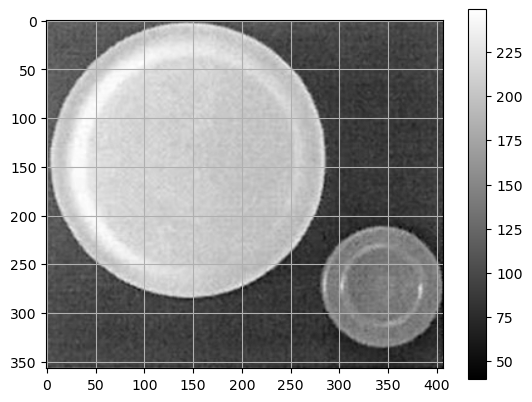

In [11]:
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.show()

1. Calculate the histogram and visualize it using matplotlib and pyplot.

```
usage: matplotlib.pyplot.hist(
         x, bins=None, range=None, density=False, weights=None,
         cumulative=False, bottom=None, histtype='bar', align='mid',
         orientation='vertical', rwidth=None, log=False, color=None,
         label=None, stacked=False, *, data=None, **kwargs
      )
```

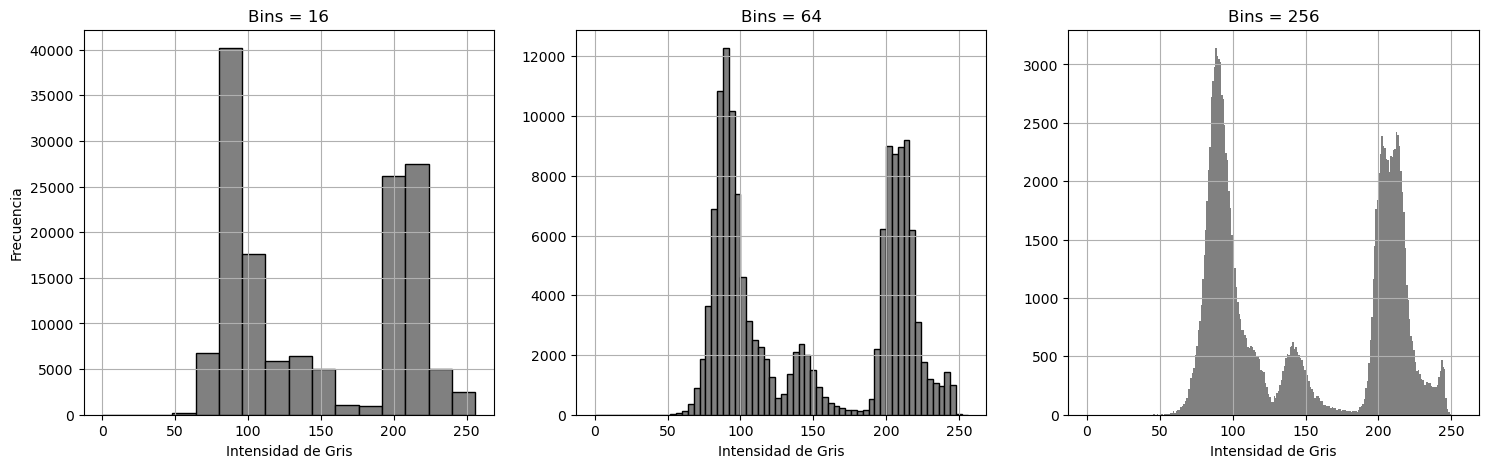

In [12]:
# Visualize the histogram with matplotlib 
# - Try at least 2 more different values for 'bins' (for example, 16, 64, 256)
# - Comment on how the appearance of the histogram changes when varying 'bins.

#YOUR CODE HERE

# 1. Calculate the histogram and visualize it using matplotlib.pyplot.hist

# Aplanamos la imagen a 1D (x) porque hist espera un array unidimensional
pixels = img.reshape(-1)

plt.figure(figsize=(18, 5))

# Caso 1: bins = 16
plt.subplot(1, 3, 1)
plt.hist(x=pixels, bins=16, range=[0, 256], color='gray', edgecolor='black')
plt.title("Bins = 16")
plt.xlabel("Intensidad de Gris"); plt.ylabel("Frecuencia")

# Caso 2: bins = 64
plt.subplot(1, 3, 2)
plt.hist(x=pixels, bins=64, range=[0, 256], color='gray', edgecolor='black')
plt.title("Bins = 64")
plt.xlabel("Intensidad de Gris")

# Caso 3: bins = 256 (Máximo detalle para 8 bits)
plt.subplot(1, 3, 3)
plt.hist(x=pixels, bins=256, range=[0, 256], color='gray')
plt.title("Bins = 256")
plt.xlabel("Intensidad de Gris")

plt.show()


#plot.hist(img.resahpe(-1), bins=256, range=[0,256])
#plt.show()

2. Do the same using the “seaborn” package.

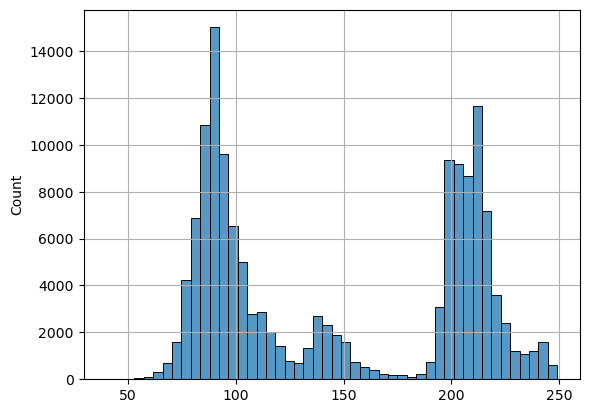

In [13]:
sns.histplot(img.reshape(-1))
plt.show()

3. Compute a smoothed version of the histogram using KDE from the
“seaborn” package.

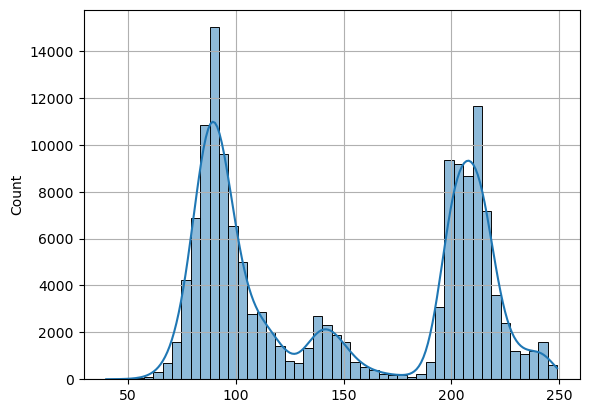

In [14]:
sns.histplot(img.reshape(-1), kde=True)
plt.show()

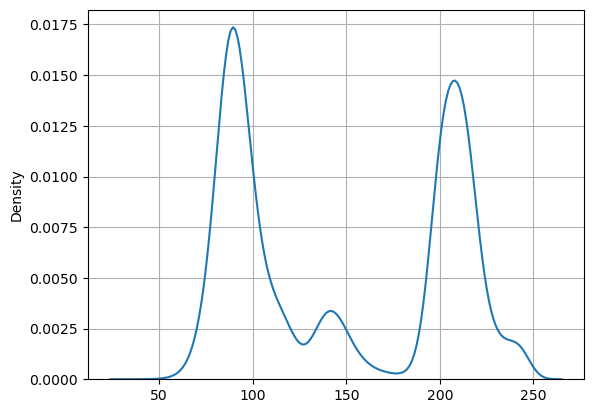

In [15]:
sns.kdeplot(img.reshape(-1))       # only kde
plt.show()

**Exercise 2 (0.05 pts):**
Apply multilevel thresholding to 'plates.png'.


1. What is the optimal number of levels?

The optimal number is 3 levels (or classes). 

Class 1 (Background): The darkest part of the image.

Class 2 (Shadow/Edge): The intermediate gray tones around the plates or in the shadows.

Class 3 (Plate): The brightest (white) part of the plates.This implies finding 2 thresholds ($T_1$ and $T_2$) that separate these three peaks.


2. How does the histogram change?

The original histogram is a "continuous" curve with peaks and valleys. The histogram of the segmented image becomes discrete: it will only have bars (non-zero frequency) at the 3 values you have chosen ($V_1, V_2, V_3$). The rest of the histogram will be empty.

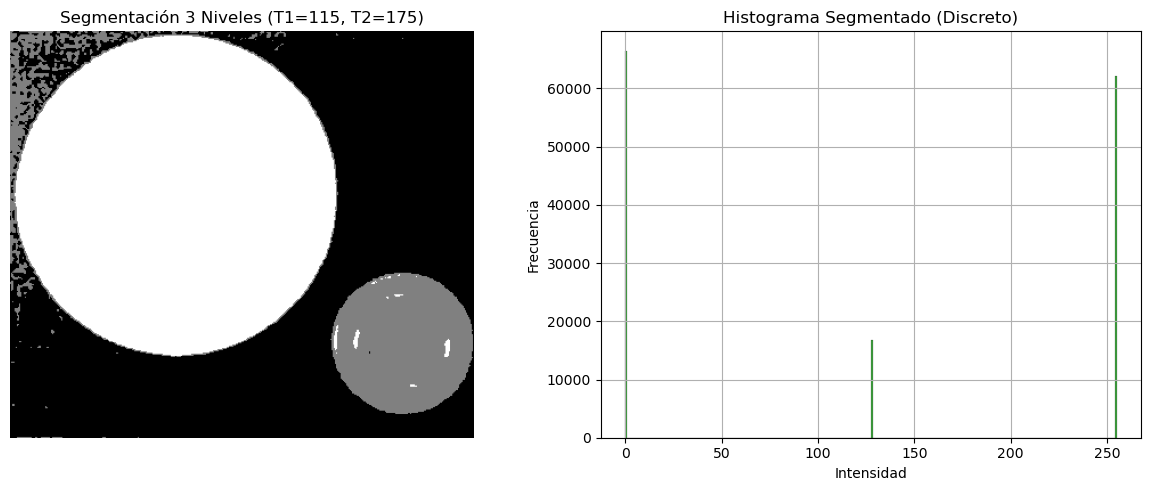

In [16]:

thresholded_img = img.copy()

# Choose your thresholds and class values based on the histogram.
# Replace the with your own values.

# Example for 3 levels (you may change the number of levels):
# Class 1: img < T1        -> V1
# Class 2: T1 <= img < T2  -> V2
# Class 3: img >= T2       -> V3

# T: Threshold
# V: Value

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Asumiendo que 'img' ya está cargada del ejercicio anterior
# Si necesitas recargarla:
# img = cv2.imread(images_path + 'plates.png', cv2.IMREAD_GRAYSCALE)

thresholded_img = img.copy()

# Definimos los Umbrales (T) basados en los valles del histograma (teoría)
T1 = 115  # Separa fondo de sombra
T2 = 175  # Separa sombra de plato

# Definimos los Valores (V) para cada clase (0=Negro, 128=Gris, 255=Blanco)
V1 = 0
V2 = 128
V3 = 255

# Aplicamos la umbralización multinivel
# Clase 1: Fondo
thresholded_img[img < T1] = V1

# Clase 2: Sombras/Bordes (Entre T1 y T2)
thresholded_img[(img >= T1) & (img < T2)] = V2

# Clase 3: Platos (Mayor que T2)
thresholded_img[img >= T2] = V3

# -------------------------------------------------------------------------
# Visualización
# -------------------------------------------------------------------------
plt.figure(figsize=(12, 5))

# 1. Imagen Segmentada
plt.subplot(1, 2, 1)
plt.imshow(thresholded_img, cmap='gray')
plt.title(f'Segmentación 3 Niveles (T1={T1}, T2={T2})')
plt.axis('off')

# 2. Histograma Resultante
plt.subplot(1, 2, 2)
# Usamos bins=256 para ver claramente que solo hay 3 barras
sns.histplot(thresholded_img.reshape(-1), bins=256, color='green')
plt.title('Histograma Segmentado (Discreto)')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

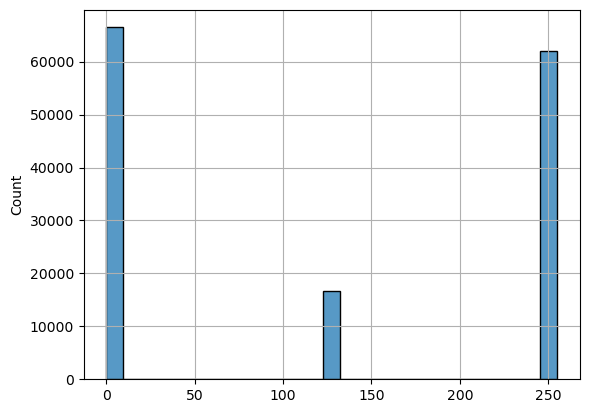

In [17]:
sns.histplot(thresholded_img.reshape(-1))
plt.show()

**Exercise 3 (0.05 pts):**
Read and visualize the image 'avocado.png', and:
1. Check the bimodal distribution of the pixels.
1. What intensity threshold would you use to segment the avocado?
1. Segment the image using the Otsu method.
   What is the estimated optimal threshold?

**Key Concepts**

***Otsu Method***: The Otsu method is used to perform automatic image
thresholding in order to separate an image into foreground and background.
It works by choosing the threshold that minimizes the intra-class variance
(or maximizes the inter-class variance) of the pixel intensities, meaning,
it finds the value that best separates the two classes.

Min pixel value = 4
Max pixel value = 255


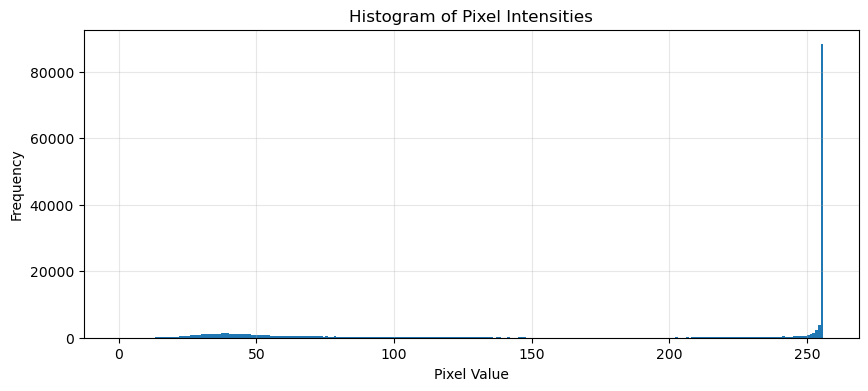

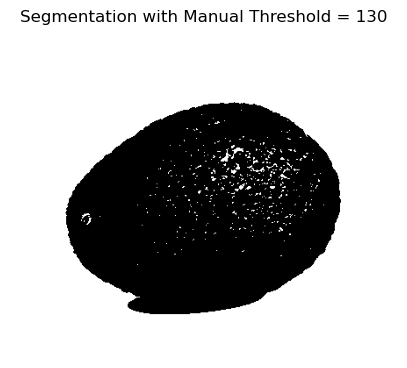

In [18]:
# Load and visualize 'avocado.png' in grayscale and inspect its histogram.
# Inspect the minimum and maximum pixel values
#    Ex.: np.min(img) and np.max(img)
# Plot the histogram of pixel intensities
# Given the histogram, decide where you would place a manual threshold to separate the avocado from the background

#YOUR CODE HERE
# img = cv2.imread(...)
#if img is None:
#    (...)
#print('Min and max pixel value =',np.min(...), ',',np.max(...))
#(...)

import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image in grayscale
img = cv2.imread('./images/avocado.png', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # Inspect the minimum and maximum pixel values
    print('Min pixel value =', np.min(img))
    print('Max pixel value =', np.max(img))

    # Plot the histogram of pixel intensities to decide the threshold
    plt.figure(figsize=(10, 4))
    plt.hist(img.ravel(), 256, [0, 256])
    plt.title('Histogram of Pixel Intensities')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- MANUAL THRESHOLD CALCULATION ---
    # Based on the histogram above, look for the valley between the two peaks.
    # Replace '100' with the value you observe in the plot.
    manual_threshold = 130
    
    # Apply the manual threshold to segment the image
    # Pixels > manual_threshold will be set to 255 (white), others to 0 (black)
    _, segmented_img_manual = cv2.threshold(img, manual_threshold, 255, cv2.THRESH_BINARY)

    # Visualize the result
    plt.figure(figsize=(5, 5))
    plt.imshow(segmented_img_manual, cmap='gray')
    plt.title(f'Segmentation with Manual Threshold = {manual_threshold}')
    plt.axis('off')
    plt.show()

else:
    print("Error: Image 'avocado.png' not found. Check the path.")





Otsu's thresholding

Estimated optimal threshold = 153.0


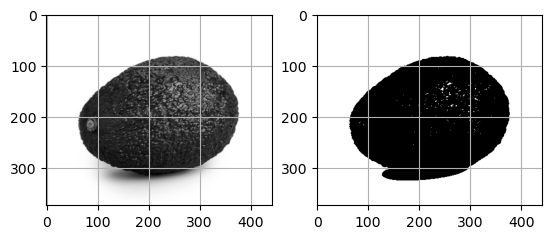

In [19]:
threshold, thresholded_img = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)
print('Estimated optimal threshold =', threshold)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(thresholded_img, cmap='gray')
plt.show()

**Exercise 4 (0.05):**
Read and visualize the image 'CT.png', and:
1. Inspect the intensity distribution of the pixels.
1. What intensity threshold would you use to segment the lungs? 60.0
1. Try to segment the lungs using the Otsu method.
   What is the estimated optimal threshold? 51.0

Min pixel value = 0
Max pixel value = 198


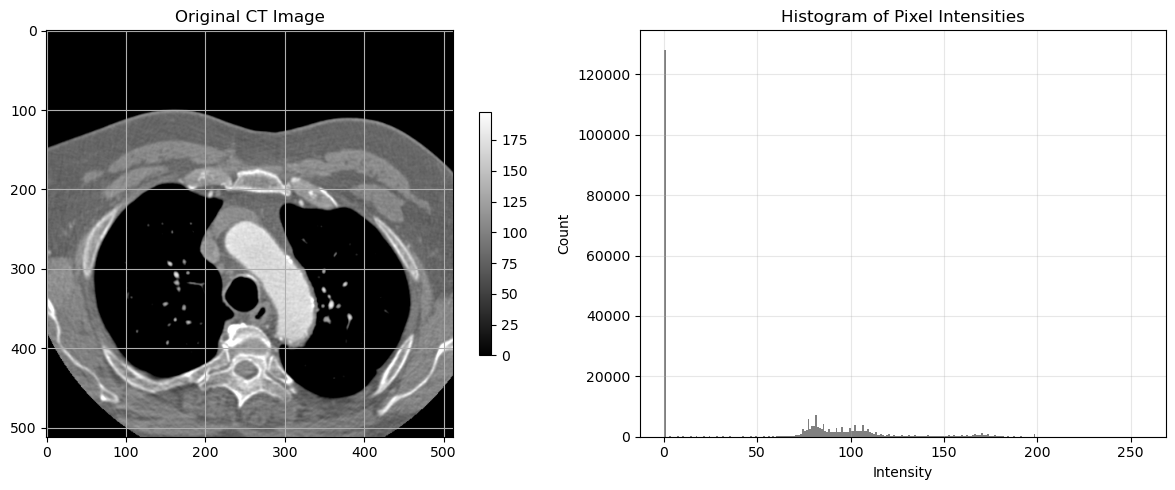

Manual Threshold selected: 60


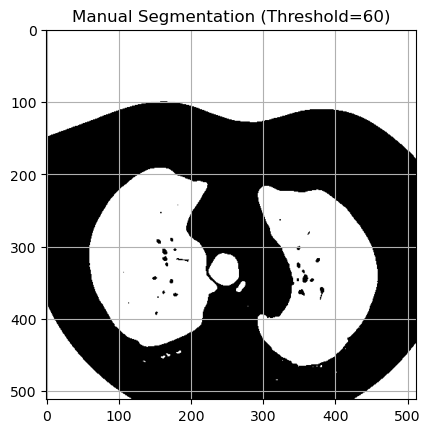

In [20]:
# Inspect the intensity distriibution of 'CT.png'
# Propose a manual threshold for segmenting the lungs based on the histogram
# Apply it and visualize the result

import cv2
import numpy as np
from matplotlib import pyplot as plt
import sys

# 1. Load the image
img_path = './images/CT.png'  # Check your path
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
  sys.exit('Input image not found, check the path')

# 2. Inspect intensity distribution (Histogram)
print('Min pixel value =', np.min(img))
print('Max pixel value =', np.max(img))

plt.figure(figsize=(12, 5))

# Plot Image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original CT Image')
plt.colorbar(shrink=0.6)

# Plot Histogram
plt.subplot(1, 2, 2)
plt.hist(img.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Pixel Intensities')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3. Manual Segmentation
# ---------------------------------------------------------------------
# We want to segment the lungs (dark pixels).
# Based on the histogram, we choose a threshold in the valley between 
# the dark peak (air) and the gray peak (tissue).
manual_thr = 60  # <--- ADJUST THIS VALUE based on the histogram observation

print(f"Manual Threshold selected: {manual_thr}")

# We use THRESH_BINARY_INV because we want the DARK pixels (lungs) to be white (255)
# Logic: If pixel < manual_thr -> 255 (Foreground/Lungs), Else -> 0 (Background)
_, manual_seg = cv2.threshold(img, manual_thr, 255, cv2.THRESH_BINARY_INV)

# Visualize the result
plt.figure()
plt.imshow(manual_seg, cmap='gray')
plt.title(f'Manual Segmentation (Threshold={manual_thr})')
plt.show()

Otsu's thresholding

Estimated optimal threshold (Otsu) = 51.0


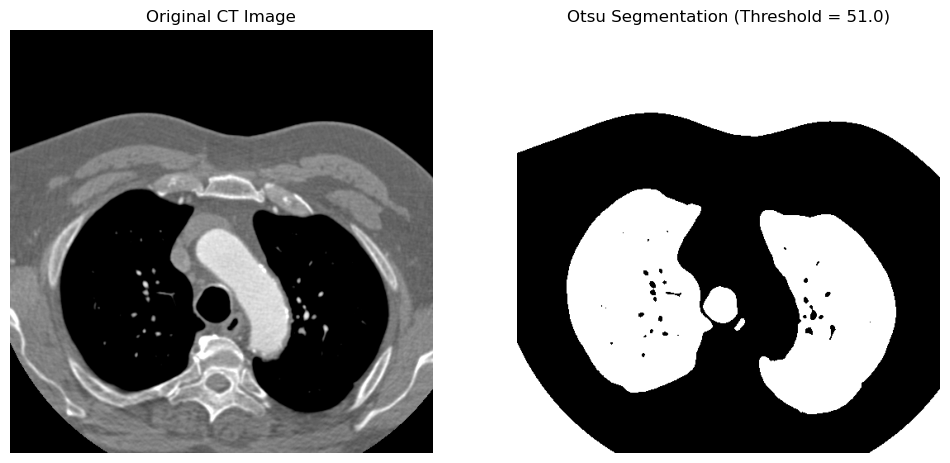

In [21]:
# Apply Otsu's method as in exercise 4 to compare both segmentations.

# We use THRESH_BINARY_INV + THRESH_OTSU because the lungs are dark (air) 
# and we want them to be the foreground (white) in the mask.
otsu_threshold, otsu_seg = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

print(f'Estimated optimal threshold (Otsu) = {otsu_threshold}')

# Visualize the comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original Image
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original CT Image')
ax[0].axis('off')

# Otsu Segmentation
ax[1].imshow(otsu_seg, cmap='gray')
ax[1].set_title(f'Otsu Segmentation (Threshold = {otsu_threshold})')
ax[1].axis('off')

plt.show()

**Exercise 5 (0.10 pts):** Using the auxiliary functions provided next:
1. Apply the Gaussian Mixture Model (GMM) method
   (e.g. the implementation in scikit-learn)
   to 'CT.png' to segment **other parts** of the image.
   First exclude the background and the lungs
   and try different number of Gaussians.
1. Would it be possible to additionally segment the bones (whitest parts)? 

In a CT scan, bones are the densest and brightest structures (highest pixel values, located on the far right of the histogram). By fitting a GMM with enough components (e.g., $k=3$ or $k=4$), the algorithm will assign one of the Gaussians specifically to these high values (the Gaussian with the highest mean $\mu$). To segment the bones, we would simply select the pixels that have the highest probability of belonging to that specific Gaussian.

**Key Concepts**

***Gaussian Mixture Model (GMM)***:
A Gaussian Mixture Model is a probabilistic model
that assumes all data points are generated from a mixture of
a finite number of Gaussian distributions with certain parameters.

Some helper functions we use later.

In [22]:
def fit_GMM(img, nb_gaussians, plot_stds=False):
  """ Fit GMM given the desired number of Gaussians. """

  gmm = mixture.GaussianMixture(n_components=nb_gaussians, max_iter=1000, covariance_type='full', random_state=1).fit(img.reshape(-1, 1))
  ordered_mu, ordered_std, ordered_pi, order = find_GMM_statistics(gmm)
  gaussian_colors = ['b','g','r','c','m','y']    # max 6 gaussians, add more if necessary
  print('Means = ', ordered_mu)
  print('Stds = ', ordered_std)
  print('Pis = ', ordered_pi)
  for i in range(nb_gaussians):
    plot_gaussian_and_stds(np.array([np.min(img), np.max(img)]), ordered_mu[i], ordered_std[i], ordered_pi[i], gaussian_colors[i], plot_stds, alpha=0.8)

  return gmm, ordered_mu, ordered_std, ordered_pi, order

def find_GMM_statistics(gmm):
  """ Determine which one is the first (lower mean),
      the second, the third, etc.  Gaussian to consistently color
      them in the plots,
      visualize the masks, etc. """

  all_means = np.array(gmm.means_[:, 0]).flatten()
  all_covariances = gmm.covariances_.flatten()

  order = np.argsort(all_means)  # this is also the label of clusters, return also 'order', useful to modify the cluster's label if necessary
  ordered_mu = all_means[order]
  ordered_std = np.sqrt(all_covariances[order])
  ordered_pi = gmm.weights_[order]

  return ordered_mu, ordered_std, ordered_pi, order

def plot_gaussian_and_stds(gaussians_range, mu, std, pi, color, plot_stds=False, alpha=1):
  """ Plot the Gaussian given by mu, std and pi.
      If plot_stds, additionally plot vertical lines corresponding to
      +-1SD, +-2SD, +-3SD """

  xmin, xmax = gaussians_range
  x = np.linspace(xmin, xmax, 1000)
  p = norm.pdf(x, mu, std) * pi
  if plot_stds:
      # plt.axvline(mu + std, 0, 1, label='pyplot vertical line', c=color)
    plt.axvline(mu + std, 0, 1, c=color, ls='--', alpha=0.75)
    plt.axvline(mu - std, 0, 1, c=color, ls='--', alpha=0.75)

    plt.axvline(mu + 2 * std, 0, 1, c=color, ls='-.', alpha=0.5)
    plt.axvline(mu - 2 * std, 0, 1, c=color, ls='-.', alpha=0.5)

    plt.axvline(mu + 3 * std, 0, 1, c=color, ls=':', alpha=0.25)
    plt.axvline(mu - 3 * std, 0, 1, c=color, ls=':', alpha=0.25)

    plt.plot(x, p, color, linewidth=2, alpha=alpha,
      label="Mean = {:.2f}; STD = {:.2f}; Weight = {:.2f}".format(mu, std, pi))

Means =  [ 0.         98.01459654]
Stds =  [1.00000000e-03 3.22300677e+01]
Pis =  [0.66329405 0.33670595]


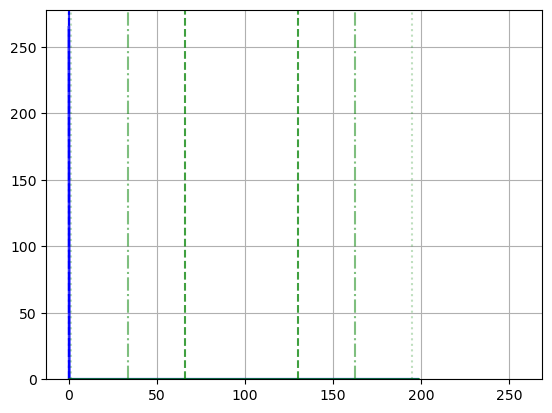

Means =  [  0.          88.06644761 166.57663669]
Stds =  [1.00000000e-03 1.97418048e+01 1.13603936e+01]
Pis =  [0.66329416 0.29404119 0.04266465]


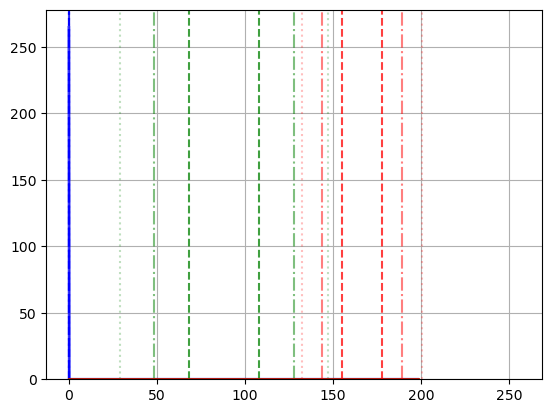

Means =  [  0.          85.83298041 106.65996245 166.15825235]
Stds =  [1.00000000e-03 1.95005277e+01 4.68804537e+00 1.17476598e+01]
Pis =  [0.66329416 0.2637267  0.02958804 0.0433911 ]


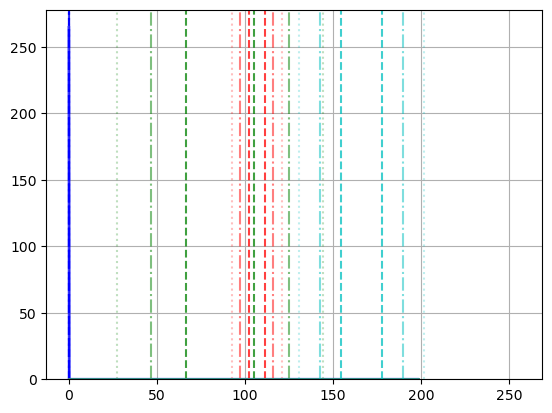

In [23]:
other_colors = img[np.where(thresholded_img==255)]      # exclude background and lungs
plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True)    # density for probability density instead of total count

gmm, ordered_mu, ordered_std, ordered_pi, order=fit_GMM(other_colors, nb_gaussians=2, plot_stds=True)
plt.show()

plt.figure()
plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True)
gmm, ordered_mu, ordered_std, ordered_pi, order=fit_GMM(other_colors, nb_gaussians=3, plot_stds=True)
plt.show()

plt.figure()
plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True)
gmm, ordered_mu, ordered_std, ordered_pi, order=fit_GMM(other_colors, nb_gaussians=4, plot_stds=True)
plt.show()

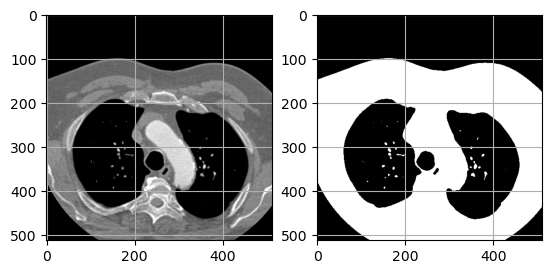

In [24]:
threshold = 50

mask = np.zeros_like(img)
mask[np.where(img > threshold)] = 1

fig, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(mask, cmap='gray')
plt.show()

Means =  [ 92.00873646 157.66226977]
Stds =  [13.76947058 19.99808484]
Pis =  [0.83491128 0.16508872]


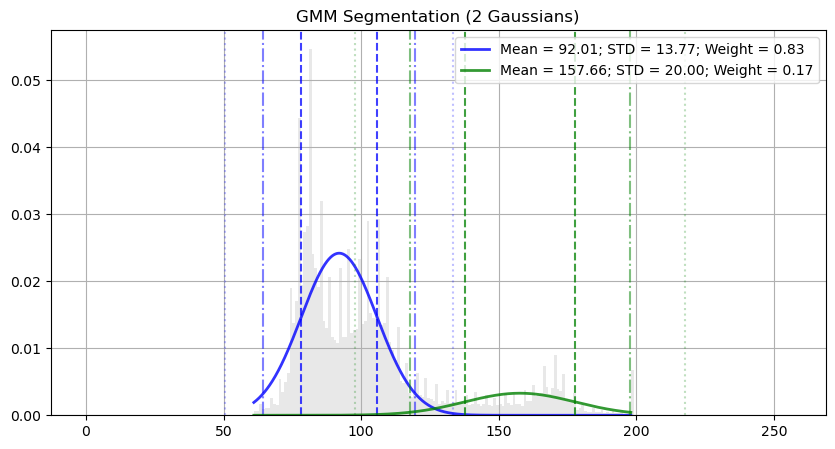

Means =  [ 80.85447484 103.26768448 157.10160637]
Stds =  [ 5.90147829  9.05724362 20.16061991]
Pis =  [0.42394259 0.40736036 0.16869706]


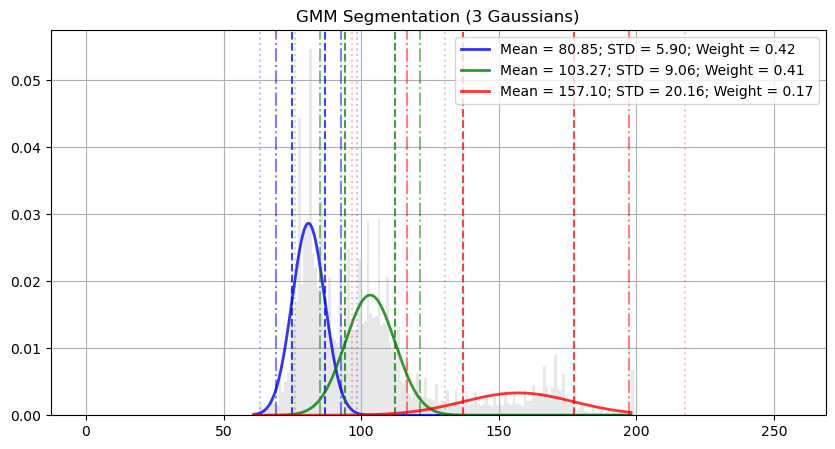

Means =  [ 81.17211553 102.96700712 129.27389615 167.83000099]
Stds =  [ 6.0462928   7.3217149  11.21054908 13.17649591]
Pis =  [0.44490598 0.36075886 0.07853736 0.11579779]


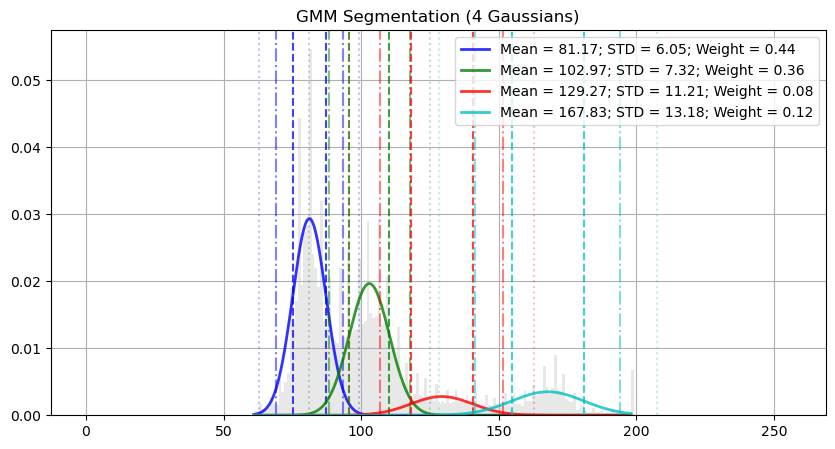

In [57]:
# -------------------------------------------------------------------------
# EXERCISE 5: MAIN EXECUTION
# -------------------------------------------------------------------------

# 1. Load image
img = cv2.imread('./images/CT.png', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # 2. Pre-processing: Exclude background and lungs
    # We established in Ex 4 that a threshold around 60 separates air/lungs from body.
    threshold = 60
    
    # We extract only the pixels belonging to the body (soft tissue + bone)
    # This removes the large peak at 0 (background/air) from the analysis
    other_colors = img[img > threshold]

    # 3. Apply GMM with different number of Gaussians (2, 3, 4)
    
    # --- Case k=2 ---
    plt.figure(figsize=(10, 5))
    # Plot normalized histogram of the body data (density=True)
    plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True, color='lightgray', alpha=0.5)
    plt.title("GMM Segmentation (2 Gaussians)")
    # Fit GMM and plot
    gmm, ordered_mu, ordered_std, ordered_pi, order = fit_GMM(other_colors, nb_gaussians=2, plot_stds=True)
    plt.legend()
    plt.show()

    # --- Case k=3 ---
    plt.figure(figsize=(10, 5))
    plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True, color='lightgray', alpha=0.5)
    plt.title("GMM Segmentation (3 Gaussians)")
    gmm, ordered_mu, ordered_std, ordered_pi, order = fit_GMM(other_colors, nb_gaussians=3, plot_stds=True)
    plt.legend()
    plt.show()

    # --- Case k=4 ---
    # With 4 Gaussians, one of them usually isolates the bones (highest mean) very well
    plt.figure(figsize=(10, 5))
    plt.hist(other_colors.reshape(-1), bins=256, range=[0, 256], density=True, color='lightgray', alpha=0.5)
    plt.title("GMM Segmentation (4 Gaussians)")
    gmm, ordered_mu, ordered_std, ordered_pi, order = fit_GMM(other_colors, nb_gaussians=4, plot_stds=True)
    plt.legend()
    plt.show()

else:
    print("Error: Image 'CT.png' not found.")

#### Clustering

**Exercise 6 (0.05 pts):** Using 'CT.png':
1. Try **several times** k-means specifying a different number of clusters.
1. What differences, if any, do you observe between each run?

As the number of clusters ($k$) increases, the algorithm segments the image into more granular levels of detail. A lower $k$ only separates the regions with high contrast (e.g., background vs. foreground), while a higher $k$ allows the model to differentiate between tissues or materials with more similar intensity values.

**Key Concepts**

***K-means***: K-means is an iterative clustering algorithm
that groups similar data points together
based on their distance to a central point, called the centroid.
The centroids represents the centers of the clusters
and are calculated as the means (or medians) of the points in the cluster.

We use the functions as imported from the scikit-learn library.

Define a convenience function to compute and show the k-means results.

In [58]:
def RunKMeans(img,k):
  kmeans = KMeans(n_clusters=k, n_init="auto").fit(img.reshape(-1, 1))
  fig, ax = plt.subplots(1, 2)
  ax[0].imshow(img, cmap='gray')
  ax[1].imshow(kmeans.labels_.reshape(img.shape))
  # plot image + labels overlayed
  plt.figure()
  plt.imshow(img, cmap='gray')
  plt.imshow(kmeans.labels_.reshape(img.shape), alpha=0.2)
  plt.colorbar()
  plt.show()

In [27]:
# Run k-means three times with different values of k (for example k=2, 3, 4)
# For each k, visualize the label mage and the overlay

#Example:
#RunKMeans(img, 2)

Run 1

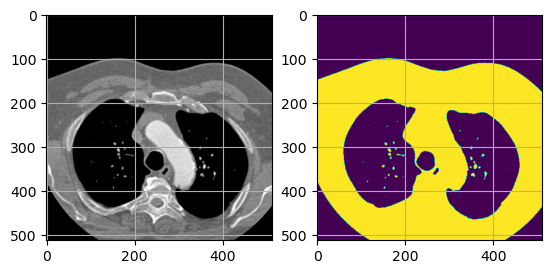

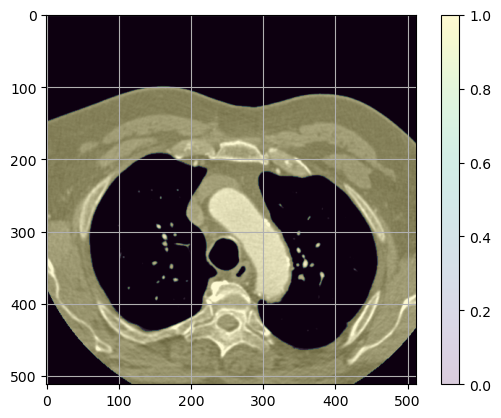

In [59]:
# Run K-means with k=2
# Expected: Separation between Air (lungs/background) and Body (tissue/bone)
RunKMeans(img, 2)

Run 2

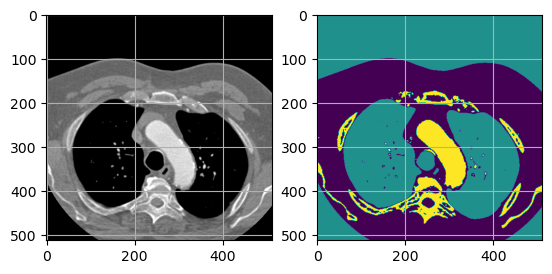

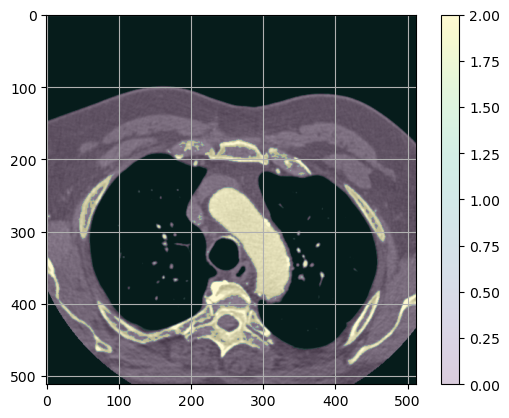

In [60]:
# Run K-means with k=3
# Expected: Separation of Air, Soft Tissue, and Bone
RunKMeans(img, 3)

Run 3

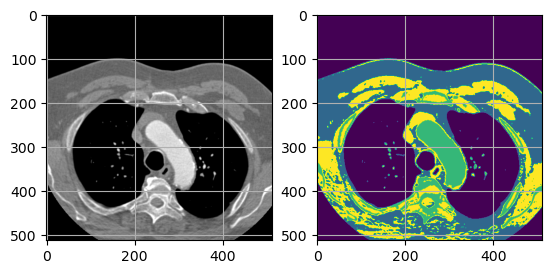

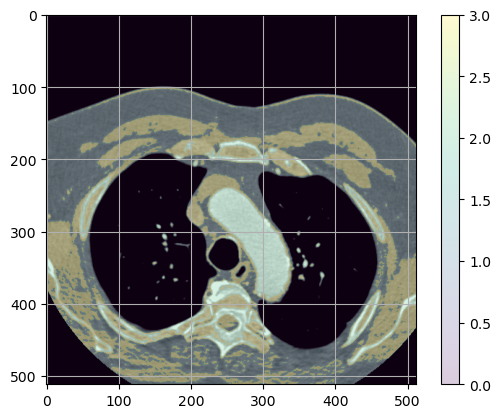

In [61]:
# Run K-means with k=4
# Expected: Further subdivision (e.g., separating background air from lung air, or different tissue densities)
RunKMeans(img, 4)

**Exercise 7 (0.05 pts):**
Read and visualize 'puncher.png' and its corresponding histogram. Then:
1. Apply k-means to segment the object.
1. Apply Meanshift to segment the object. Try different 'bandwidth' values.

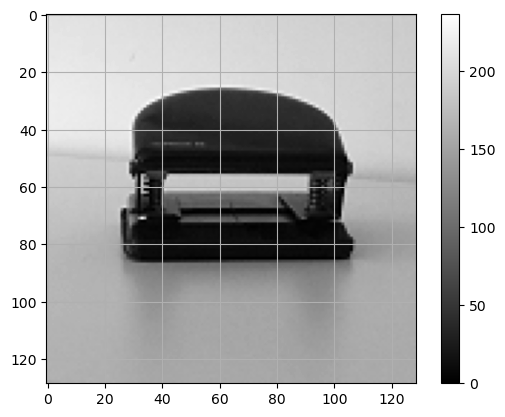

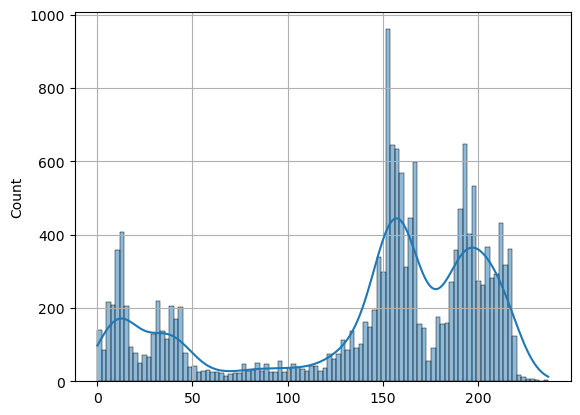

In [31]:
img = cv2.imread(images_path + 'puncher.png', cv2.IMREAD_GRAYSCALE)
if img is None:
  sys.exit('Input image not found, check the path')

plt.imshow(img, cmap='gray')
plt.colorbar()
plt.figure()
sns.histplot(img.reshape(-1), bins=100, kde=True)
plt.show()

In [32]:
#Apply K-means (calling RunKMeans) to segment the object from the background, try with k=2

#YOUR CODE HERE


Meanshift with default bandwidth (this might take some time, be patient).

Found 2 clusters


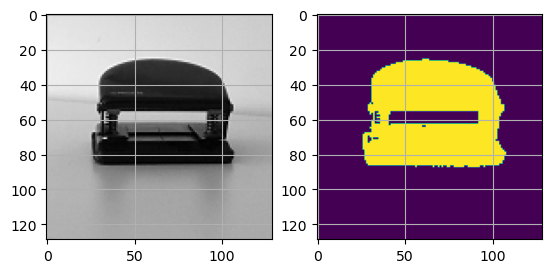

In [33]:
ms_default = MeanShift().fit(img.reshape(-1, 1))

print('Found', len(np.unique(ms_default.labels_)), 'clusters')
fig, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(ms_default.labels_.reshape(img.shape))
plt.show()

Meanshift with different bandwidths.
We first define a convenience function to run experiments more easily.

In [34]:
def RunMeanShift(img, bw):
  ms = MeanShift(bandwidth=bw).fit(img.reshape(-1, 1))
  print('Found', len(np.unique(ms.labels_)), 'clusters')
  fig, ax = plt.subplots(1, 2)
  ax[0].imshow(img, 'gray')
  ax[1].imshow(ms.labels_.reshape(img.shape))
  plt.show()

In [35]:
# Using the RunMeanShift function defined above, run MeanShift with at least two different bandwidth values (e.g. 5, 10, 20)

#YOUR CODE HERE

**Exercise 8 (0.25 pts):**
Now we work with an example that uncovers some of the short-commings
of the methods seen so far. Our goal is to separate the foreground
of a not so well taken photograph of a sudoku game.
Naturally, we consider as foreground the numbers and the gridlines.

In [36]:
img = cv2.imread(images_path + 'sudoku.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
  sys.exit('Input image not found, check the path')

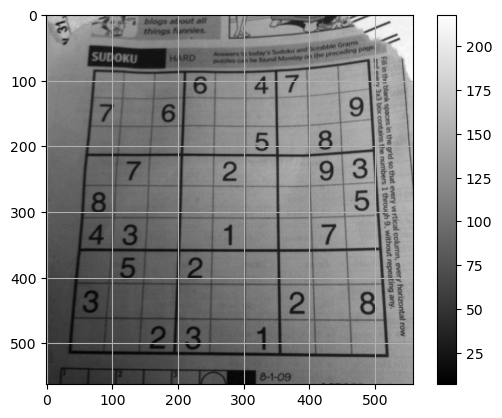

In [37]:
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.show()

We calculate the histogram and visualize it using matplotlib and pyplot.


In [38]:
#YOUR CODE HERE


We do the same using the “seaborn” package.

In [39]:
#YOUR CODE HERE


We compute a smoothed version of the histogram using KDE from the
“seaborn” package.

In [40]:
#YOUR CODE HERE


Apply global thresholding to 'sudoku.jpg'.
Can you find a number of levels to separate the foreground
(i.e. the numbers and the gridlines)?

In [41]:
#Try to separate the foreground (digits and grid lines) from the background. You can refresh your memory by looking at exercise 2

#YOUR CODE HERE



Let's try Otsu's thresholding.

In [42]:
#Apply Otsu's method (revisit exercise 3 and 4) 

# YOUR CODE HERE


How do you rate the performance of Otsu's thresholding?

Let's try with Gaussian Mixture Model. What would be a good number of Gaussians to model the data?

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.18315221e-06,
        1.27326088e-05, 2.54652177e-05, 1.20959784e-04, 2.10088046e-04,
        2.38736416e-04, 7.51223922e-04, 1.30190925e-03, 1.26052828e-03,
        1.07590545e-03, 8.46718488e-04, 9.45396207e-04, 1.12046958e-03,
        1.33692393e-03, 1.82394622e-03, 2.29823590e-03, 2.52105655e-03,
        1.93853970e-03, 2.00856905e-03, 2.26003807e-03, 2.25048861e-03,
        2.36189894e-03, 2.02130165e-03, 2.13589513e-03, 1.92899024e-03,
        1.85259459e-03, 2.04995002e-03, 2.21865709e-03, 2.21547394e-03,
        2.43829459e-03, 2.46694296e-03, 2.35871579e-03, 2.47012612e-03,
        2.33643372e-03, 2.36826525e-03, 2.19000872e-03, 2.13271198e-03,
        2.40646307e-03, 2.64201634e-03, 3.06219243e-03, 3.15768699e-03,
        3.32639406e-03, 3.35822558e-03, 3.22453319e-03, 3.30411200e-03,
        3.62879352e-03, 4.05533592e-03, 4.29407233e-03, 4.822475

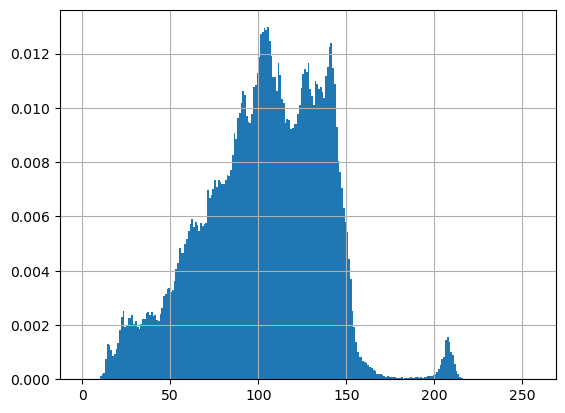

In [43]:
#YOUR CODE HERE (Exercise 5)

plt.hist(img.reshape(-1), bins=256, range=[0, 256], density=True)    # density for probability density instead of total count



Does the GMM fit our needs here?

Let's try with k-means. What number of clusters would you choose?

In [44]:
#Run K-means with several values of k
# Based on the reults, what number of clusters would you choose and why?



Let's try with meanshift.
(This might take even more time compared to above.)

In [45]:
#Run MeanShift wirh a bandwidth of 6 and inspect the result.



How do these two methods handle the problem?

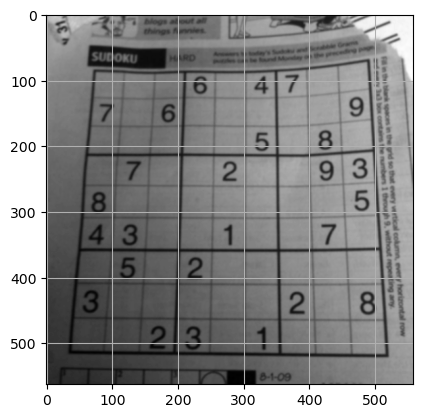

In [46]:
#Finally, try Gaussian blur and adaptative thresholding on 'sudoku,jpg'

blurred_img = cv2.GaussianBlur(img, (5,5), 0)
plt.imshow(blurred_img, cmap='gray')
plt.show()

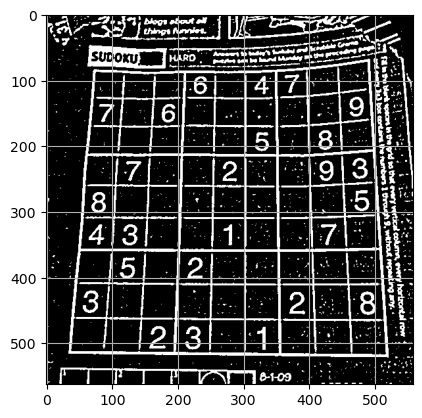

In [47]:
thresholded_img = cv2.adaptiveThreshold(blurred_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
plt.imshow(thresholded_img, cmap='gray')
plt.show()

1. Argue what this type of adaptive thresholding actually does.
1. Try to improve the chosen parameters.
1. Suggest how you would proceed to segment the foreground
   we are interested in.

**Exercise 9 (0.05 pts):**
Read and visualize the image 'fieldWheat.png',
and use k-means (**with number of clusters=3**) to segment:
1. The field of wheat alone. Save the resulting image.
1. The whole sky (clear sky and clouds)

- **Note 1:** If more than 1 feature
  (e.g. 'R', 'G', and 'B' in a color image) is given,
  each feature should be given as a column.
- **Note 2:** Remember that different initializations may lead to
  different clusters.

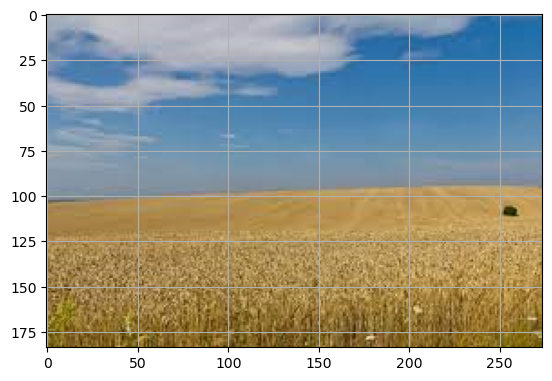

In [48]:
img = cv2.imread(images_path + 'field.png')      # cv2 reads it BGR order
if img is None:
  sys.exit('Input image not found, check the path')

plt.imshow(img[...,::-1])   # IMPORTANT --> matplotlib requires RGB order
plt.show()

In [49]:
X = np.array([img[:, :, 0].reshape(-1), img[:, :, 1].reshape(-1), img[:, :, 2].reshape(-1)]).T
print(X.shape)

(50416, 3)


In [50]:
#  - Apply K-means with k = 3 to the RGB pixels in X.
#  - Reshape the labels to the image shape and visualize the cluster map.
#  - Overlay the clustering result on the original image.
#  - Inspect the cluster centers and decide which cluster corresponds to:
#       - The wheat field
#       - The sky (clear sky + clouds)
#       - Any remaining region


# YOUR CODE HERE
# Example steps (to be implemented by you):
# kmeans = KMeans(n_clusters=??, n_init="auto").fit(??)
# kmeans_labels = kmeans.labels_.reshape([img.shape[0], img.shape[1]])
# ...
#print(kmeans.cluster_centers_)


**Exercise 10 (0.15 pts): Density-based clustering**
1. Load 'matrix2.dat' data (data generated with 1 run of the code showed next. Note that each run will produce a different dataset. This is why we provide the file matrix2.dat, but you can generate different datasets and see how the clustering algorithm works on different situations).
1. Apply DBSCAN to segment the custers you observe.

In [51]:
# Code to generate a new dataset

# 2 clusters + noise
# X = np.concatenate((
#     np.random.normal(0, 10, (50, 2)),    # loc, scale, size. This one, noise-like
#     np.random.normal(3, 1, (250, 2)),
#     np.random.normal(10, 1, (400, 2))))

# 3 clusters + noise
# X = np.concatenate((
#     np.random.normal(0, 10, (50, 2)),    # loc, scale, size. This one, noise-like
#     np.random.normal(3, 1, (250, 2)),
#     np.random.normal(10, 1, (400, 2)),
#     np.random.normal(-10, 2, (100, 2))))
# # save it
# X.dump("other_matrix.dat")

In [52]:
X = np.load("matrix2.dat", allow_pickle=True)
plt.scatter(X[:, 0], X[:, 1])
plt.title("Data")
plt.show()

UnpicklingError: Failed to interpret file 'matrix2.dat' as a pickle

First, let's see what k-means can do... You may need to adjust the number of clusters in the code.

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
ax[0].scatter(X[:, 0], X[:, 1])
ax[0].set_title("Data")

ax[1].scatter(X[:, 0], X[:, 1], c=kmeans_labels)
ax[1].set_title("K Means Clustering")
plt.show()

Now, let's apply density-based clustering with DBSCAN to see if we can improve the results.

In [ ]:
clustering1 = DBSCAN().fit(X)      # default eps = 0.5, min_samples=5
print('Found', len(np.unique(clustering1.labels_))-1, 'clusters:', np.unique(clustering1.labels_))

clustering2 = DBSCAN(eps=3, min_samples=3).fit(X)
print('Found', len(np.unique(clustering2.labels_))-1, 'clusters:', np.unique(clustering2.labels_))

your bet:

In [ ]:
# Choose values for eps and min_samples that you think might detect only the clearest clusters in the data.
# Fit DBSCAN with your parameters.
# Compare your results with clustering1 and clustering2 in a single figure



Do you have any idea how we might automize the search for good
DBSCAN parameters that match our expectations?